In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import parse_slurm as ps
import data_analysis as da
import glob
import pandas as pd

In [3]:
metric = 'Elapsed'

# Docking Protein-Protein Execution Time Analysis 

In [8]:
dpp = pd.read_csv('./data/data_dpp.csv')
dpp_time = dpp[['Elapsed', 'NCPUS']]

## Descriptive Analysis

In [9]:
for x in [4, 8, 16, 32]:
    group = ps.get_group(dpp_time, ncpus=x)
    print(group.describe())

         Elapsed  NCPUS
count  13.000000   13.0
mean    1.344274    4.0
std     0.138089    0.0
min     1.210556    4.0
25%     1.238056    4.0
50%     1.271667    4.0
75%     1.491667    4.0
max     1.582778    4.0
         Elapsed  NCPUS
count  16.000000   16.0
mean    0.720521    8.0
std     0.038328    0.0
min     0.682222    8.0
25%     0.693472    8.0
50%     0.715972    8.0
75%     0.721528    8.0
max     0.825556    8.0
         Elapsed  NCPUS
count  10.000000   10.0
mean    0.465306   16.0
std     0.036696    0.0
min     0.440556   16.0
25%     0.444306   16.0
50%     0.448194   16.0
75%     0.460139   16.0
max     0.539722   16.0
         Elapsed  NCPUS
count  13.000000   13.0
mean    0.366838   32.0
std     0.013245    0.0
min     0.349444   32.0
25%     0.356944   32.0
50%     0.368056   32.0
75%     0.369444   32.0
max     0.393611   32.0


## Boxplots

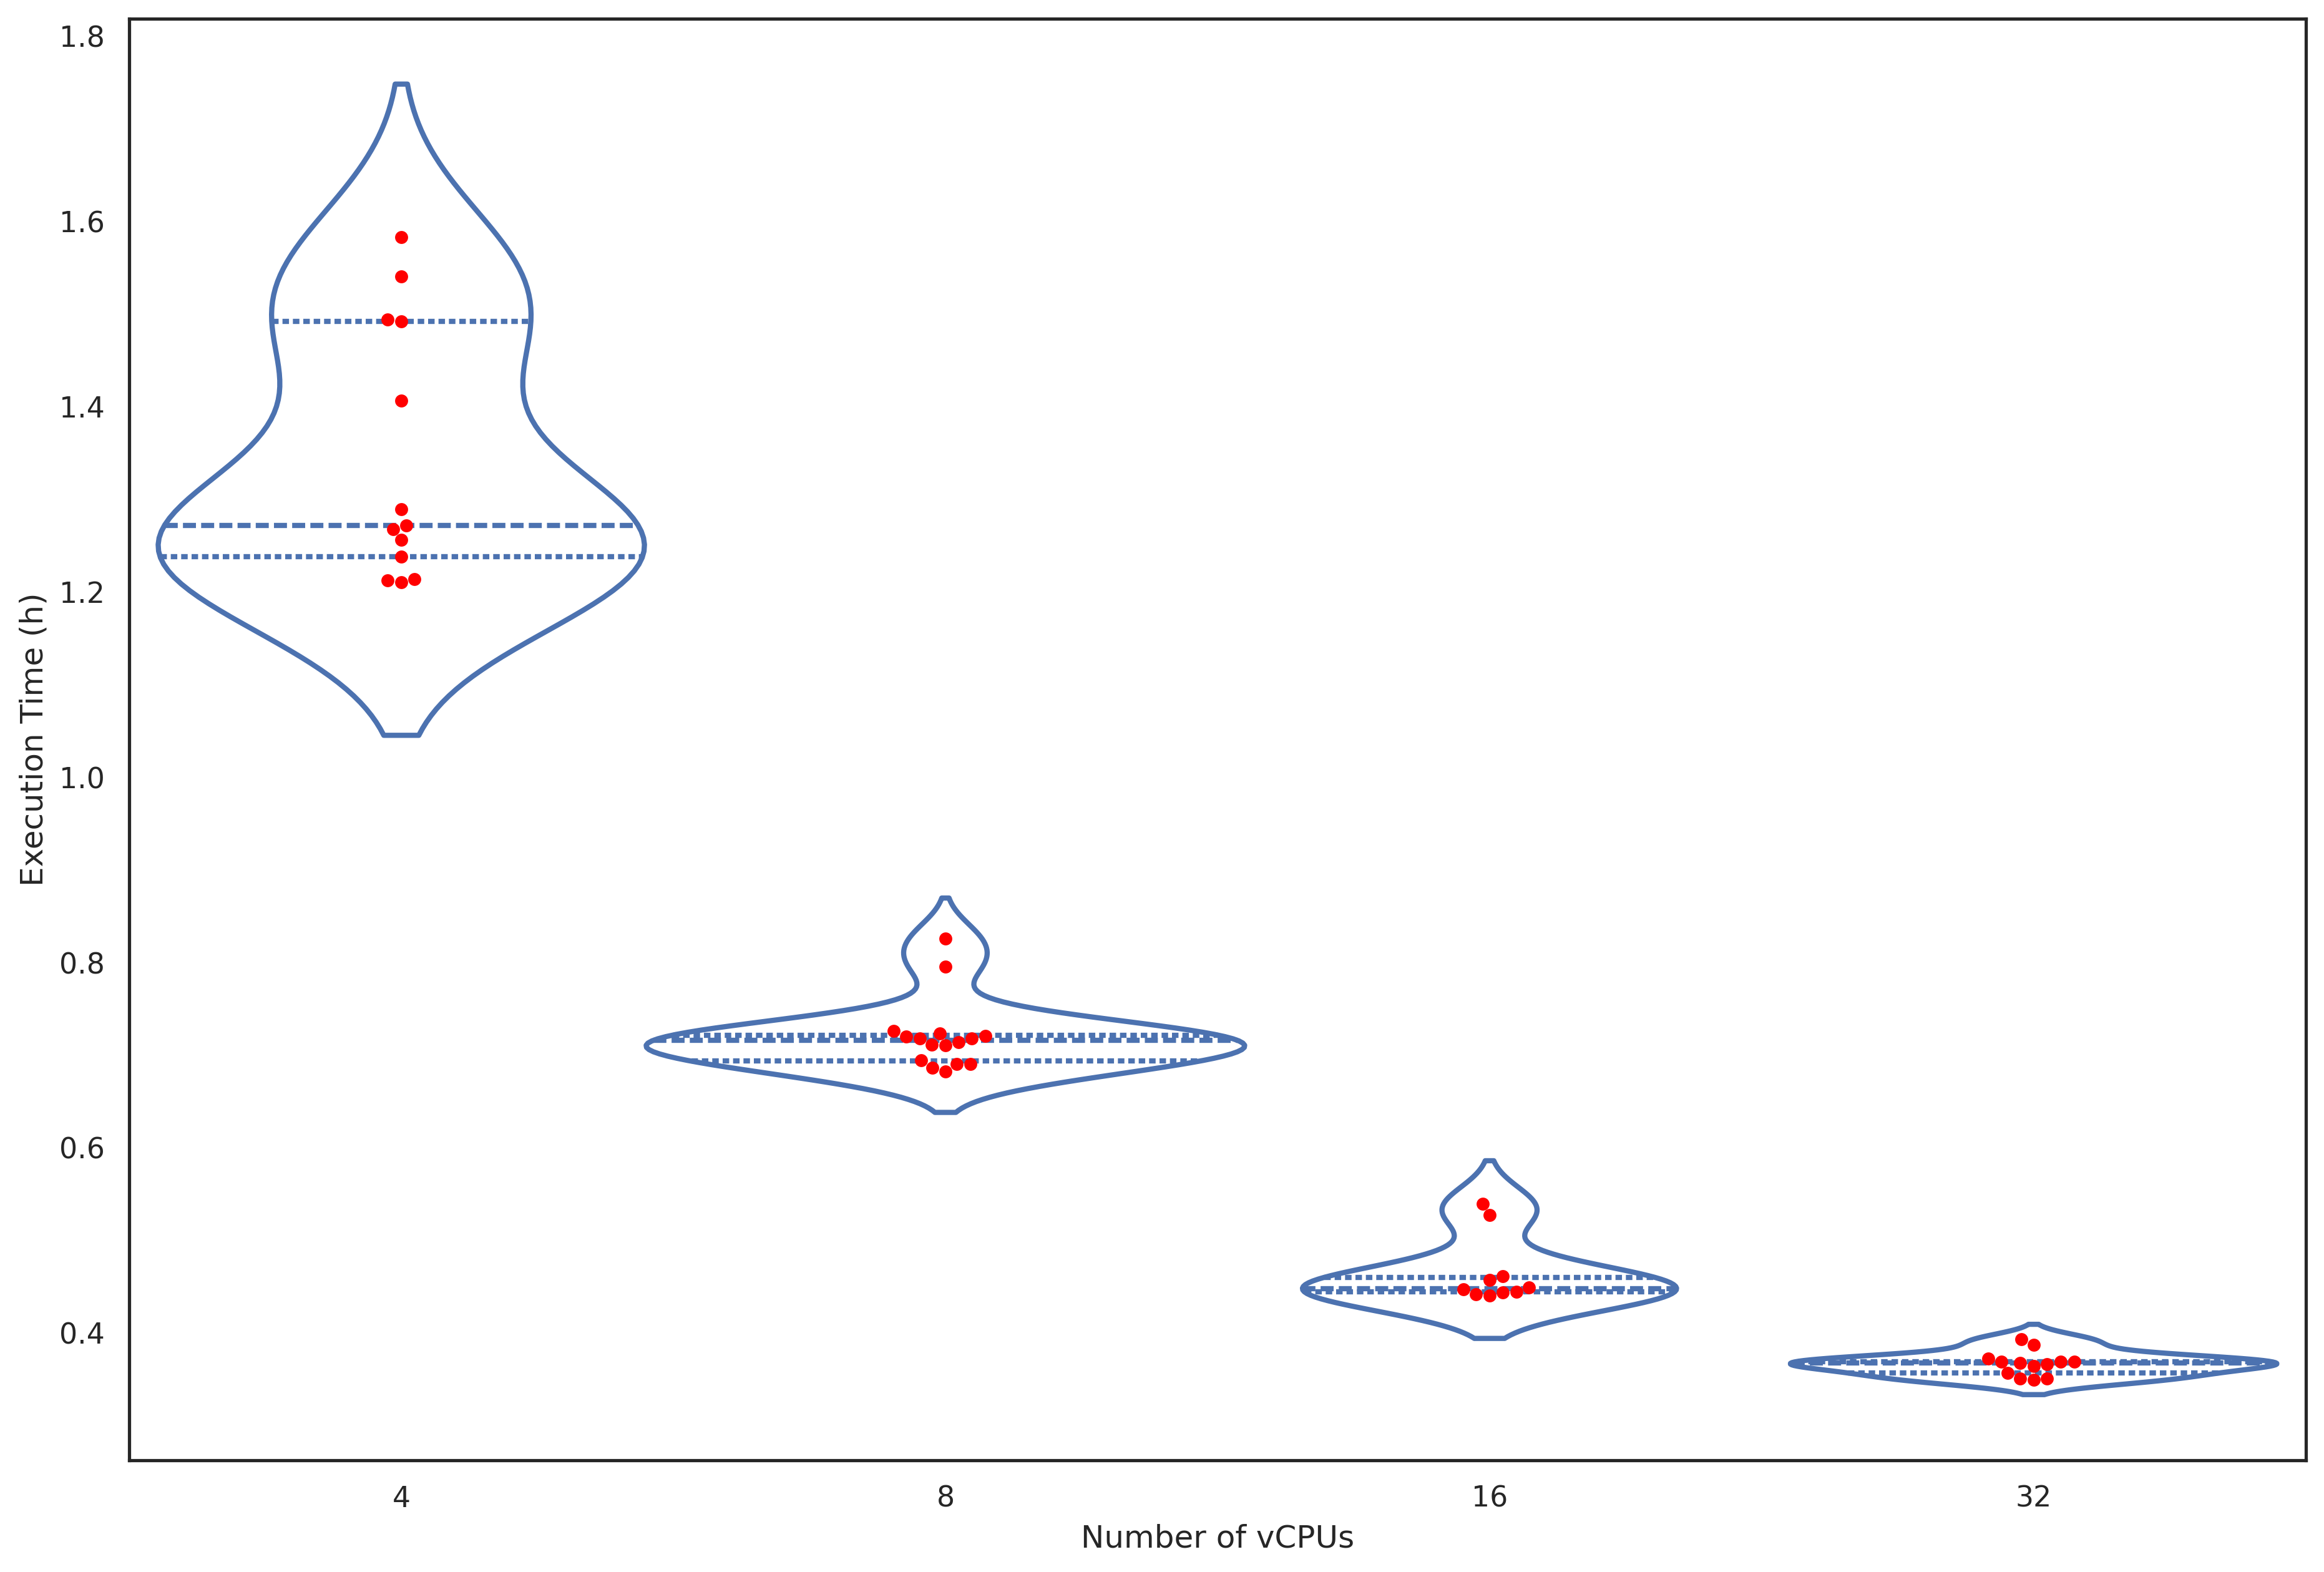

In [10]:
da.show_boxplot(
    dpp_time, "Execution Time of DPP Workflow at Varying Parallelism Degrees", metric=metric,
    x_label="Number of vCPUs", y_label="Execution Time (h)", store=True
)

### Normality Test: Shapiro-Wilk and QQ-Plots

In [11]:
normality = ps.test_normality(dpp_time, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.834655  0.018128
1      8  0.754557  0.000721
2     16  0.674254  0.000430
3     32  0.912741  0.199909


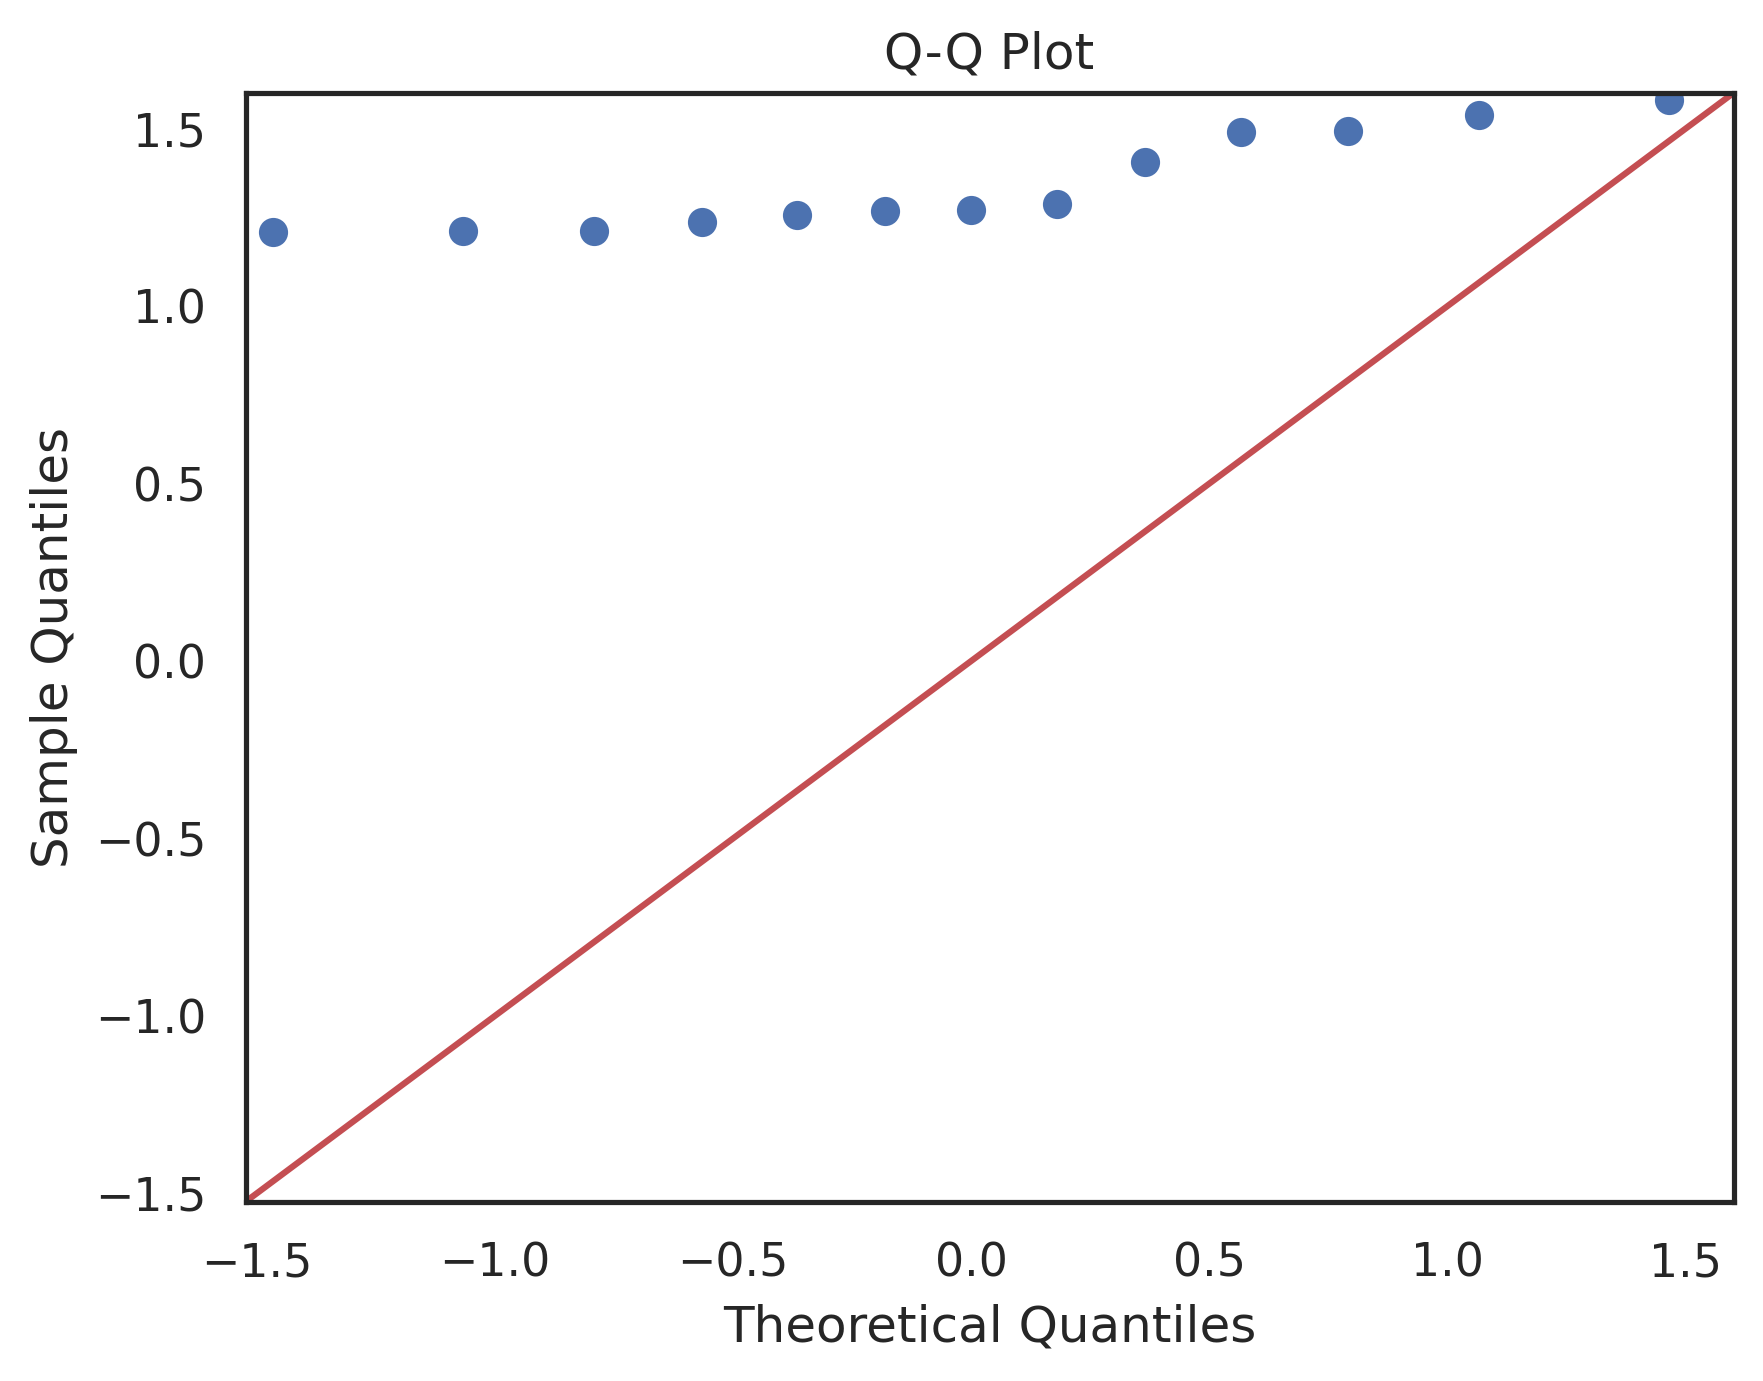

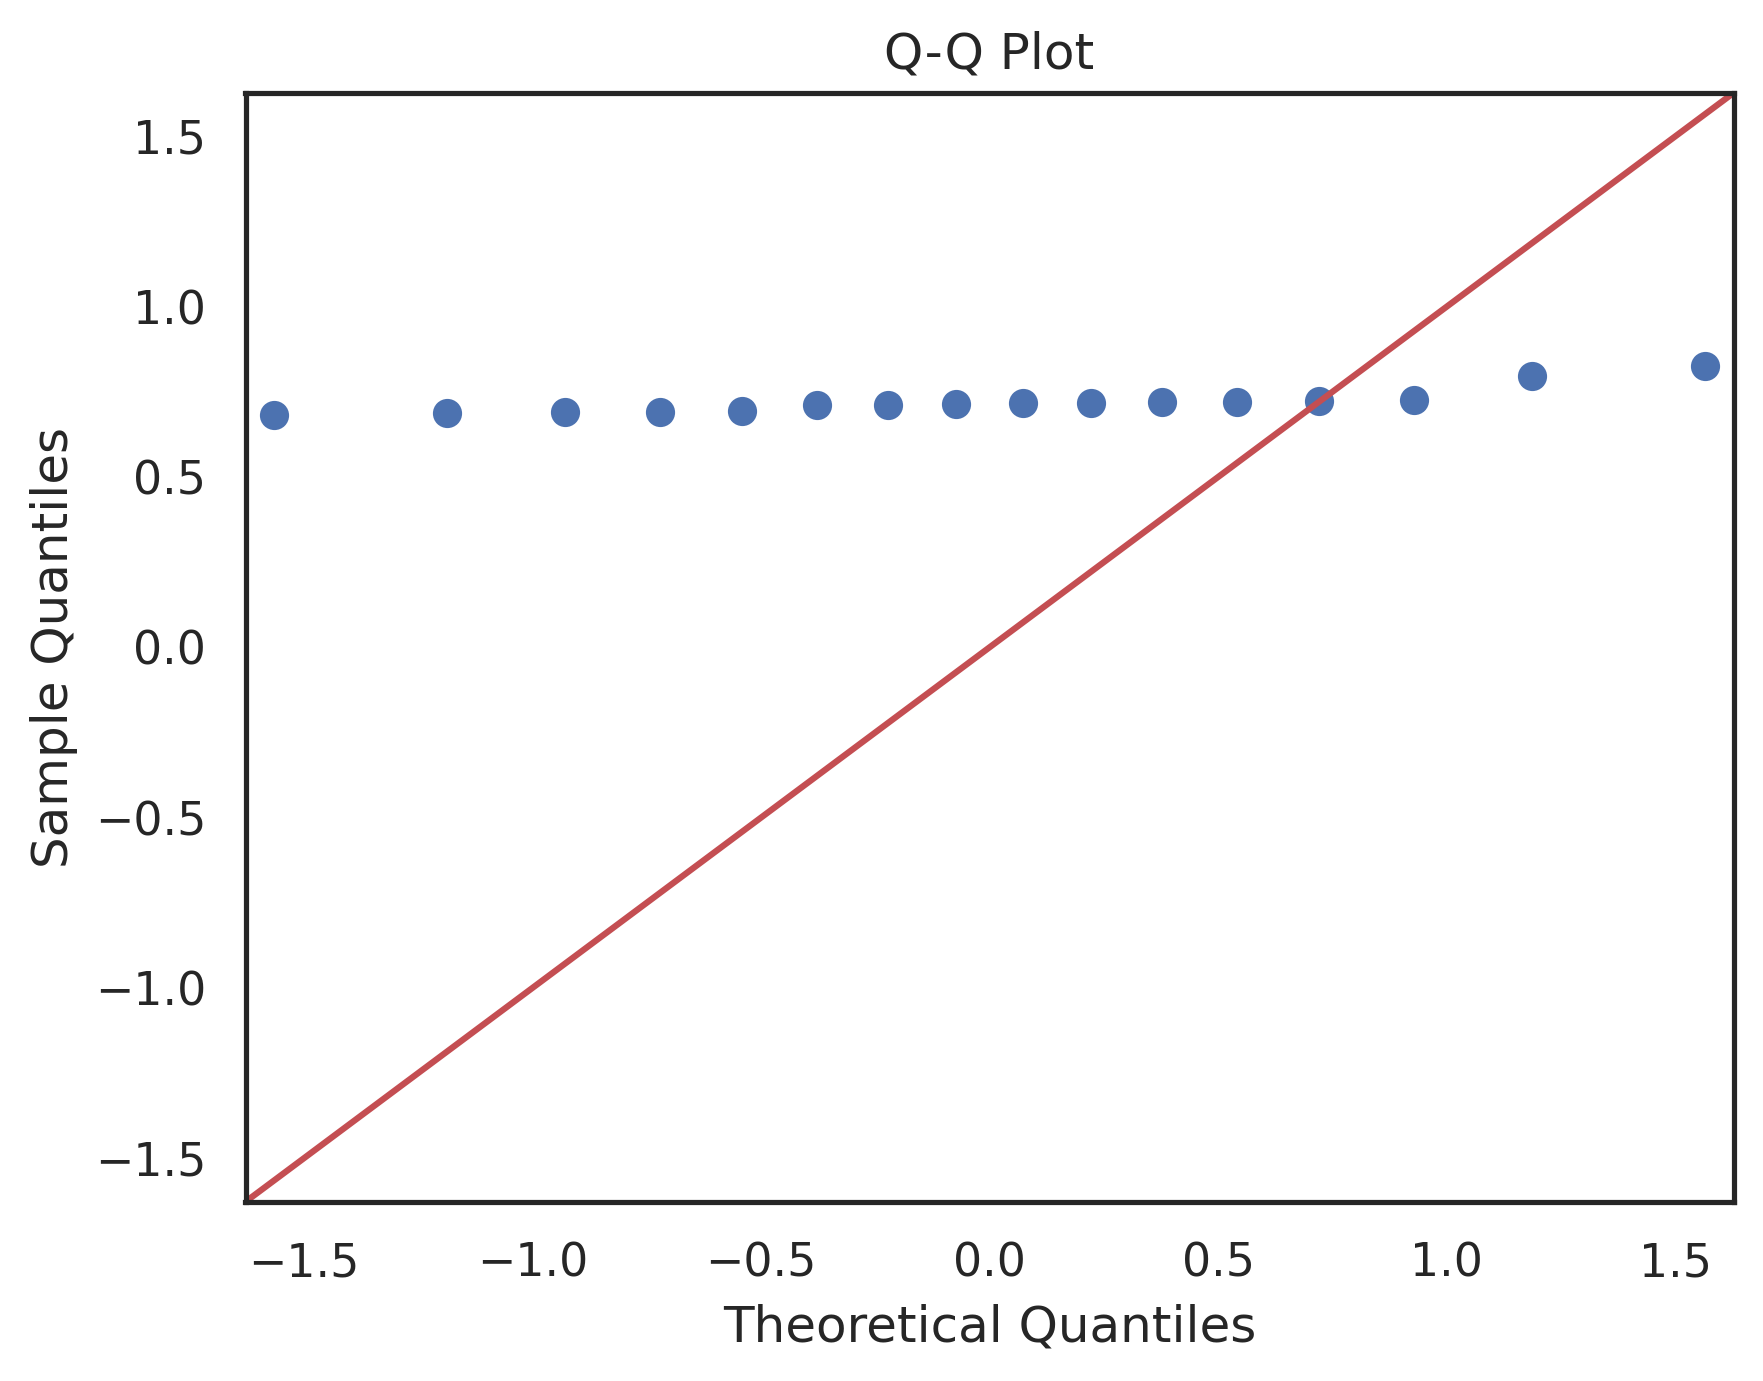

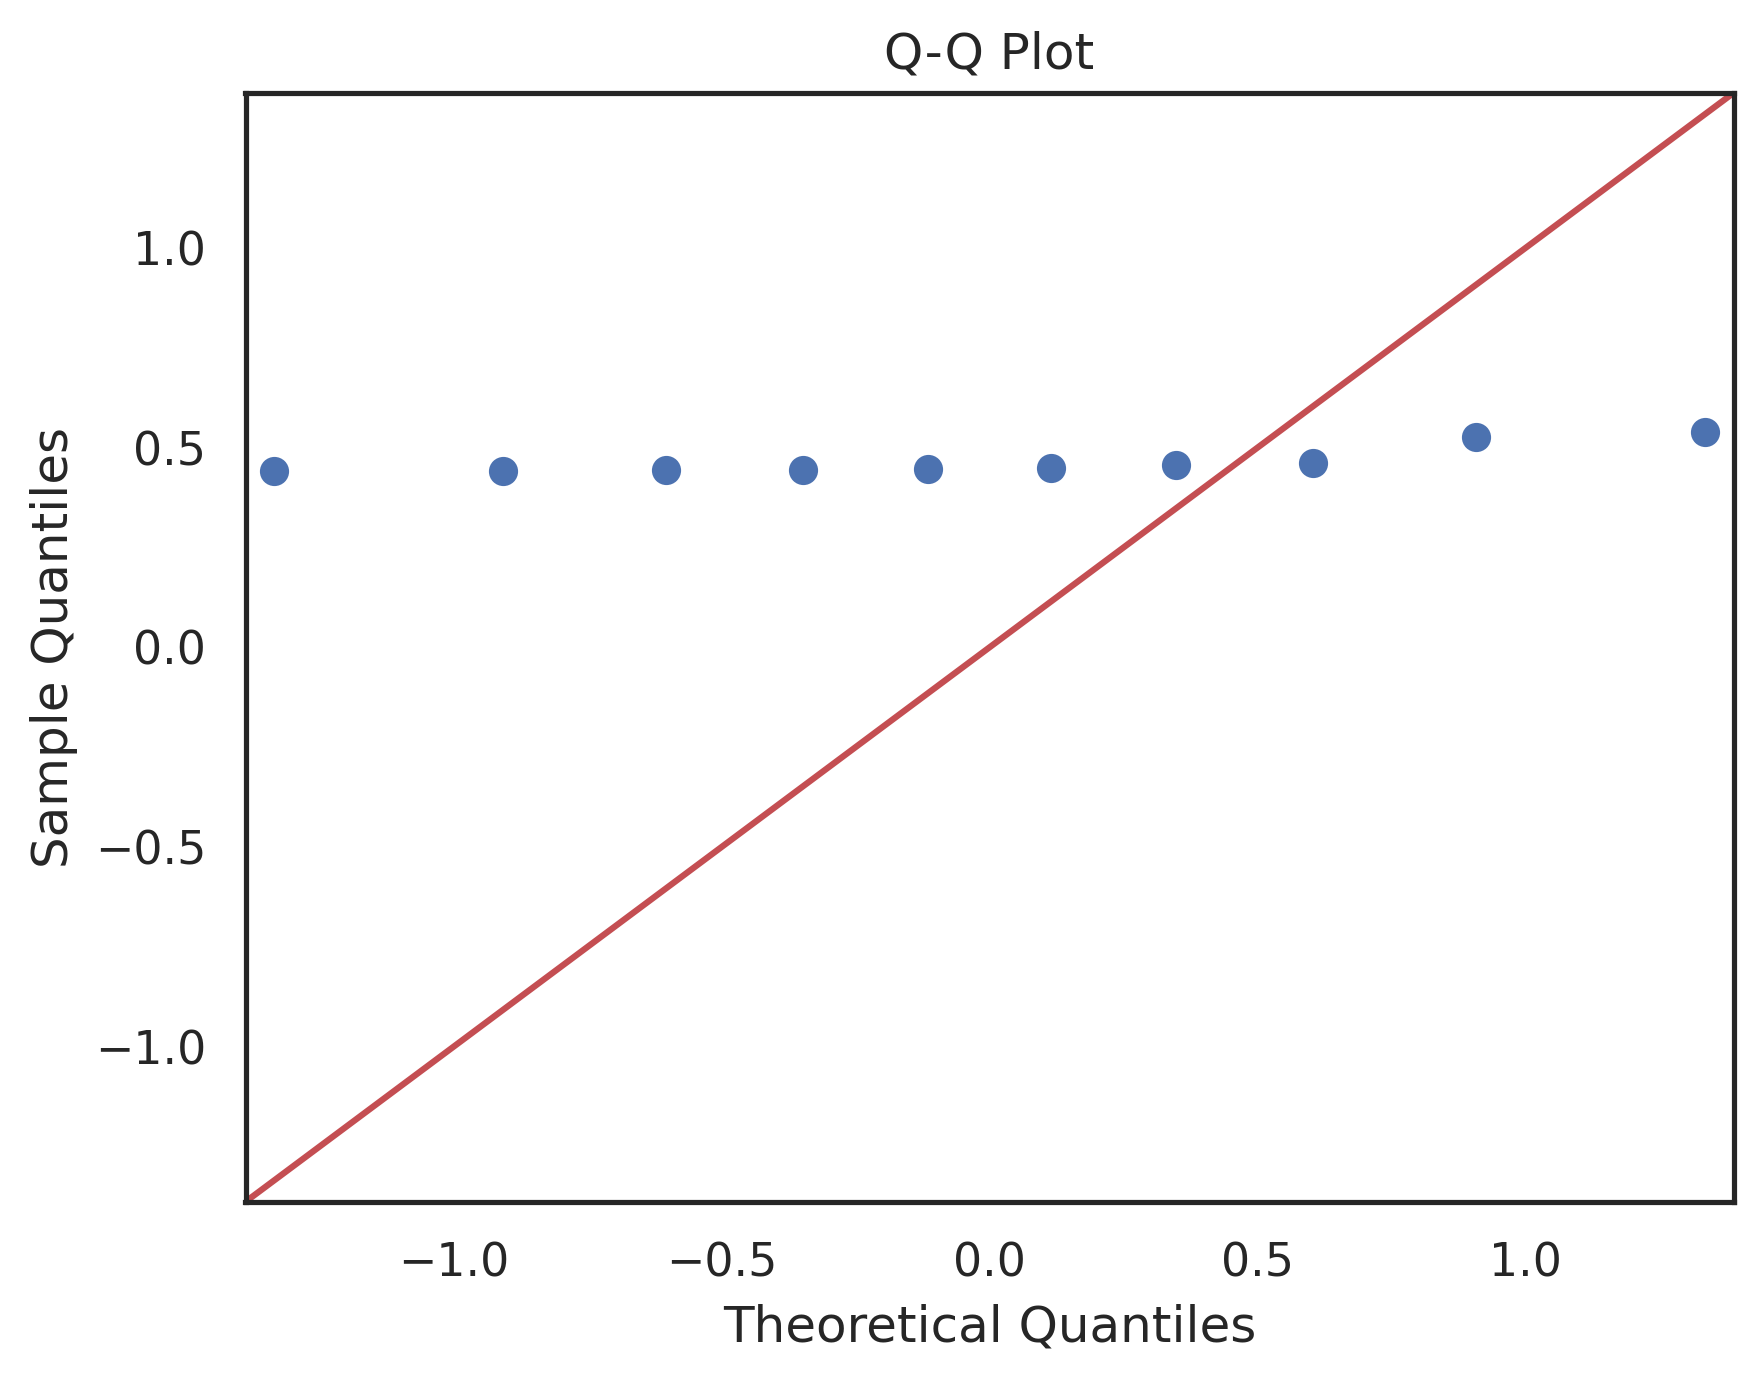

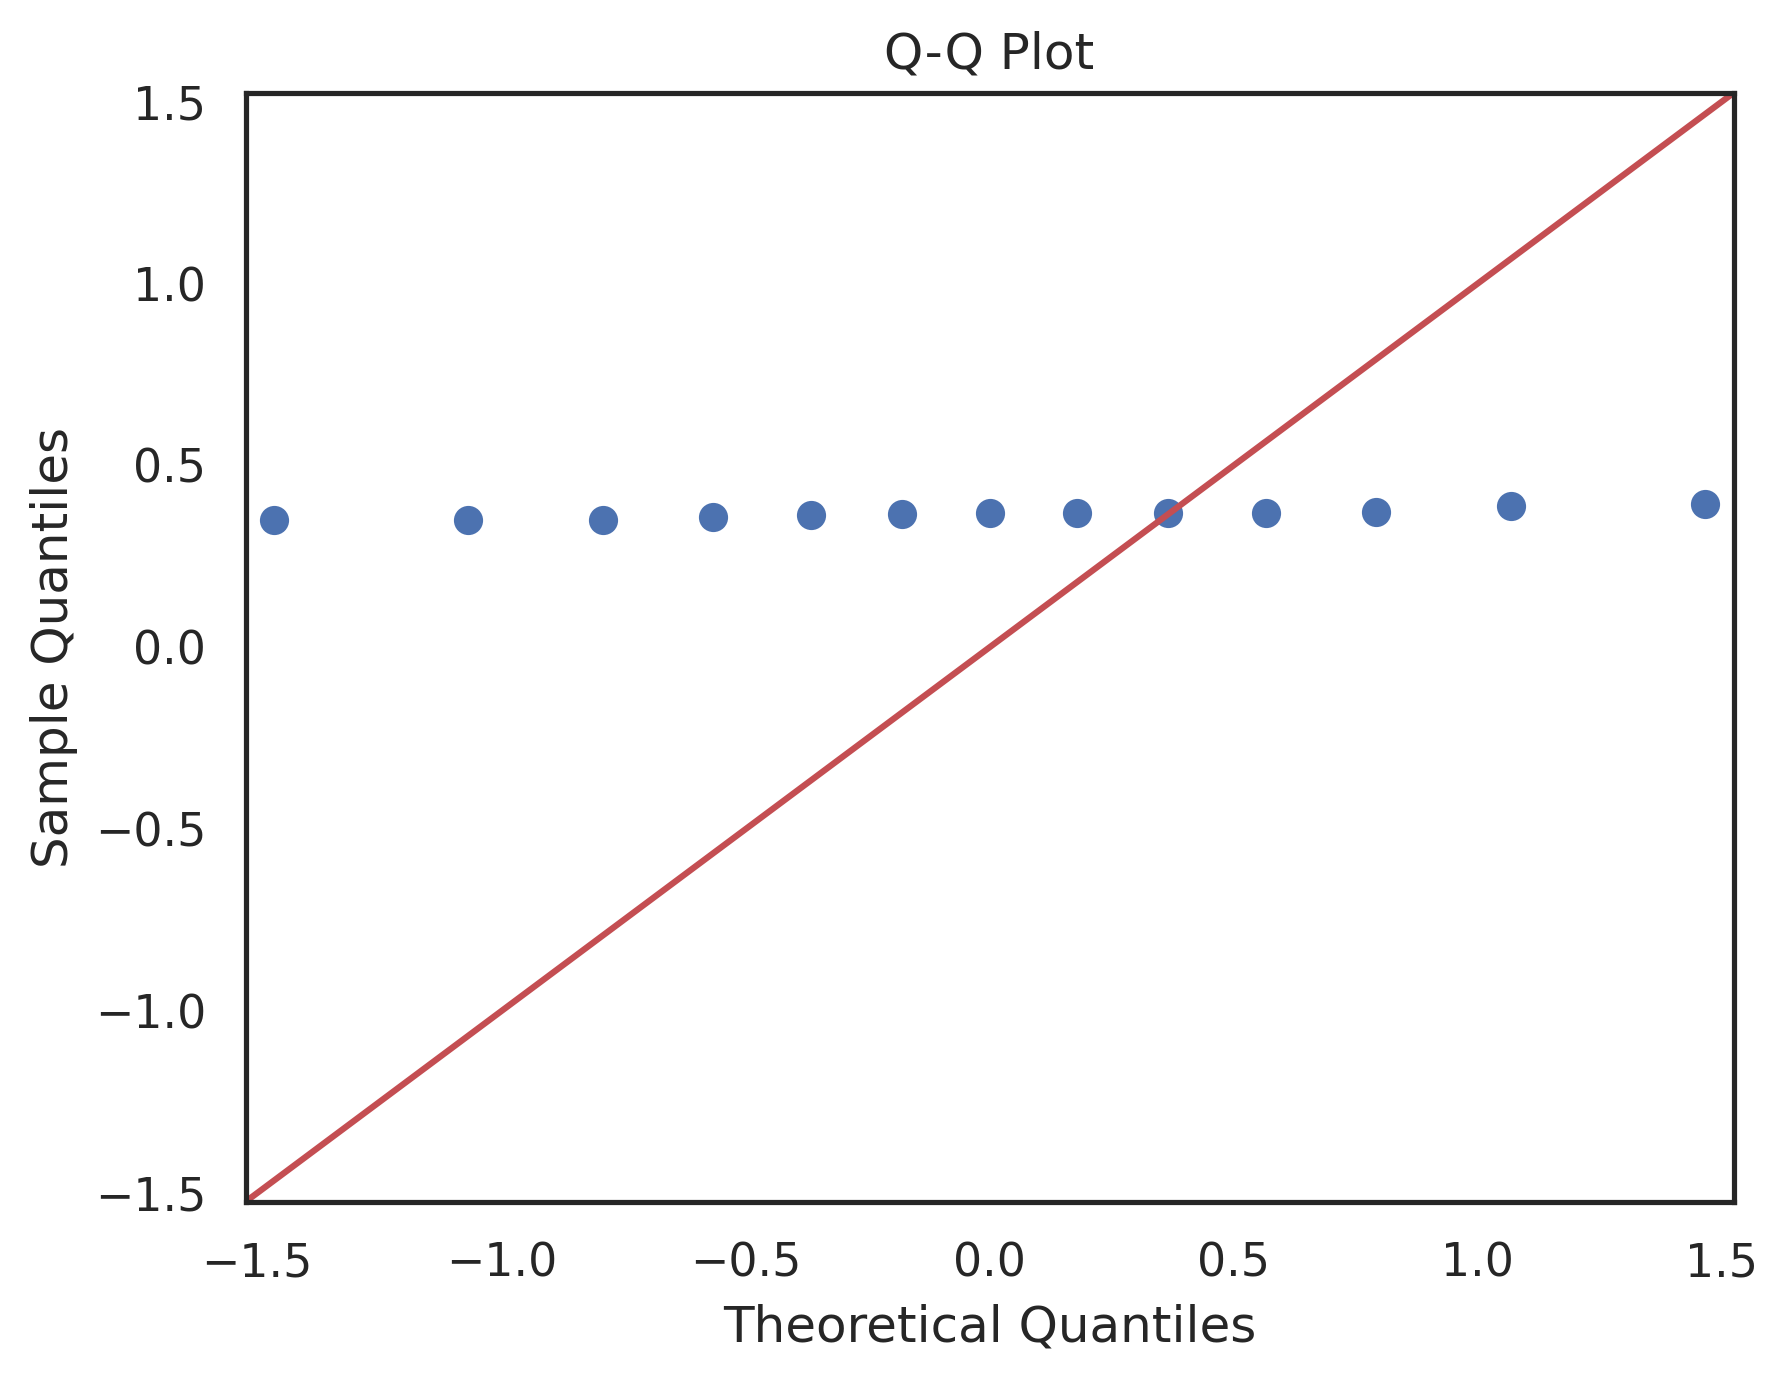

In [12]:
ps.generate_qq(dpp_time, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [13]:
ps.test_hypothesis_kruskal(dpp_time, column=metric)

(47.57750266808964, 2.6192309993255507e-10)

## Effect Size: Cliff's Delta

In [14]:
ps.calc_cliffs_delta(dpp_time, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",1.0,large
1,"(8, 16)",1.0,large
2,"(16, 32)",1.0,large


## Effect Size: Percentage Improvement

In [15]:
ps.calc_groups_improvement(dpp_time, column=metric)

,CPU-GROUPS,Mean Improvement,Median Improvement,Mean Delta,Median Delta
0,"(4, 8)",86.569693,77.613967,0.623753,0.555694
1,"(8, 16)",54.848964,59.745894,0.255215,0.267778
2,"(16, 32)",26.842381,21.773585,0.098468,0.080139
3,"(4, 32)",266.449208,245.509434,0.977436,0.903611


# Docking Antibody-Antigen Execution Time Analysis 

In [24]:
daa = pd.read_csv('./data/data_daa.csv')
daa_time = daa[['Elapsed', 'NCPUS']]

# Descriptive Analysis

In [25]:
for x in [4, 8, 16, 32]:
    group = ps.get_group(daa_time, ncpus=x)
    print(group.describe())

         Elapsed  NCPUS
count  12.000000   12.0
mean   17.805093    4.0
std     0.591620    0.0
min    17.175278    4.0
25%    17.372500    4.0
50%    17.680278    4.0
75%    18.099653    4.0
max    19.200556    4.0
         Elapsed  NCPUS
count  14.000000   14.0
mean   10.183790    8.0
std     0.386490    0.0
min     9.835000    8.0
25%     9.893681    8.0
50%    10.081528    8.0
75%    10.266597    8.0
max    11.016111    8.0
         Elapsed  NCPUS
count  10.000000   10.0
mean    6.132139   16.0
std     0.113159    0.0
min     5.980278   16.0
25%     6.028125   16.0
50%     6.151111   16.0
75%     6.221597   16.0
max     6.277500   16.0
         Elapsed  NCPUS
count  11.000000   11.0
mean    4.801717   32.0
std     0.132084    0.0
min     4.606667   32.0
25%     4.701111   32.0
50%     4.833333   32.0
75%     4.907778   32.0
max     4.965000   32.0


## Boxplots

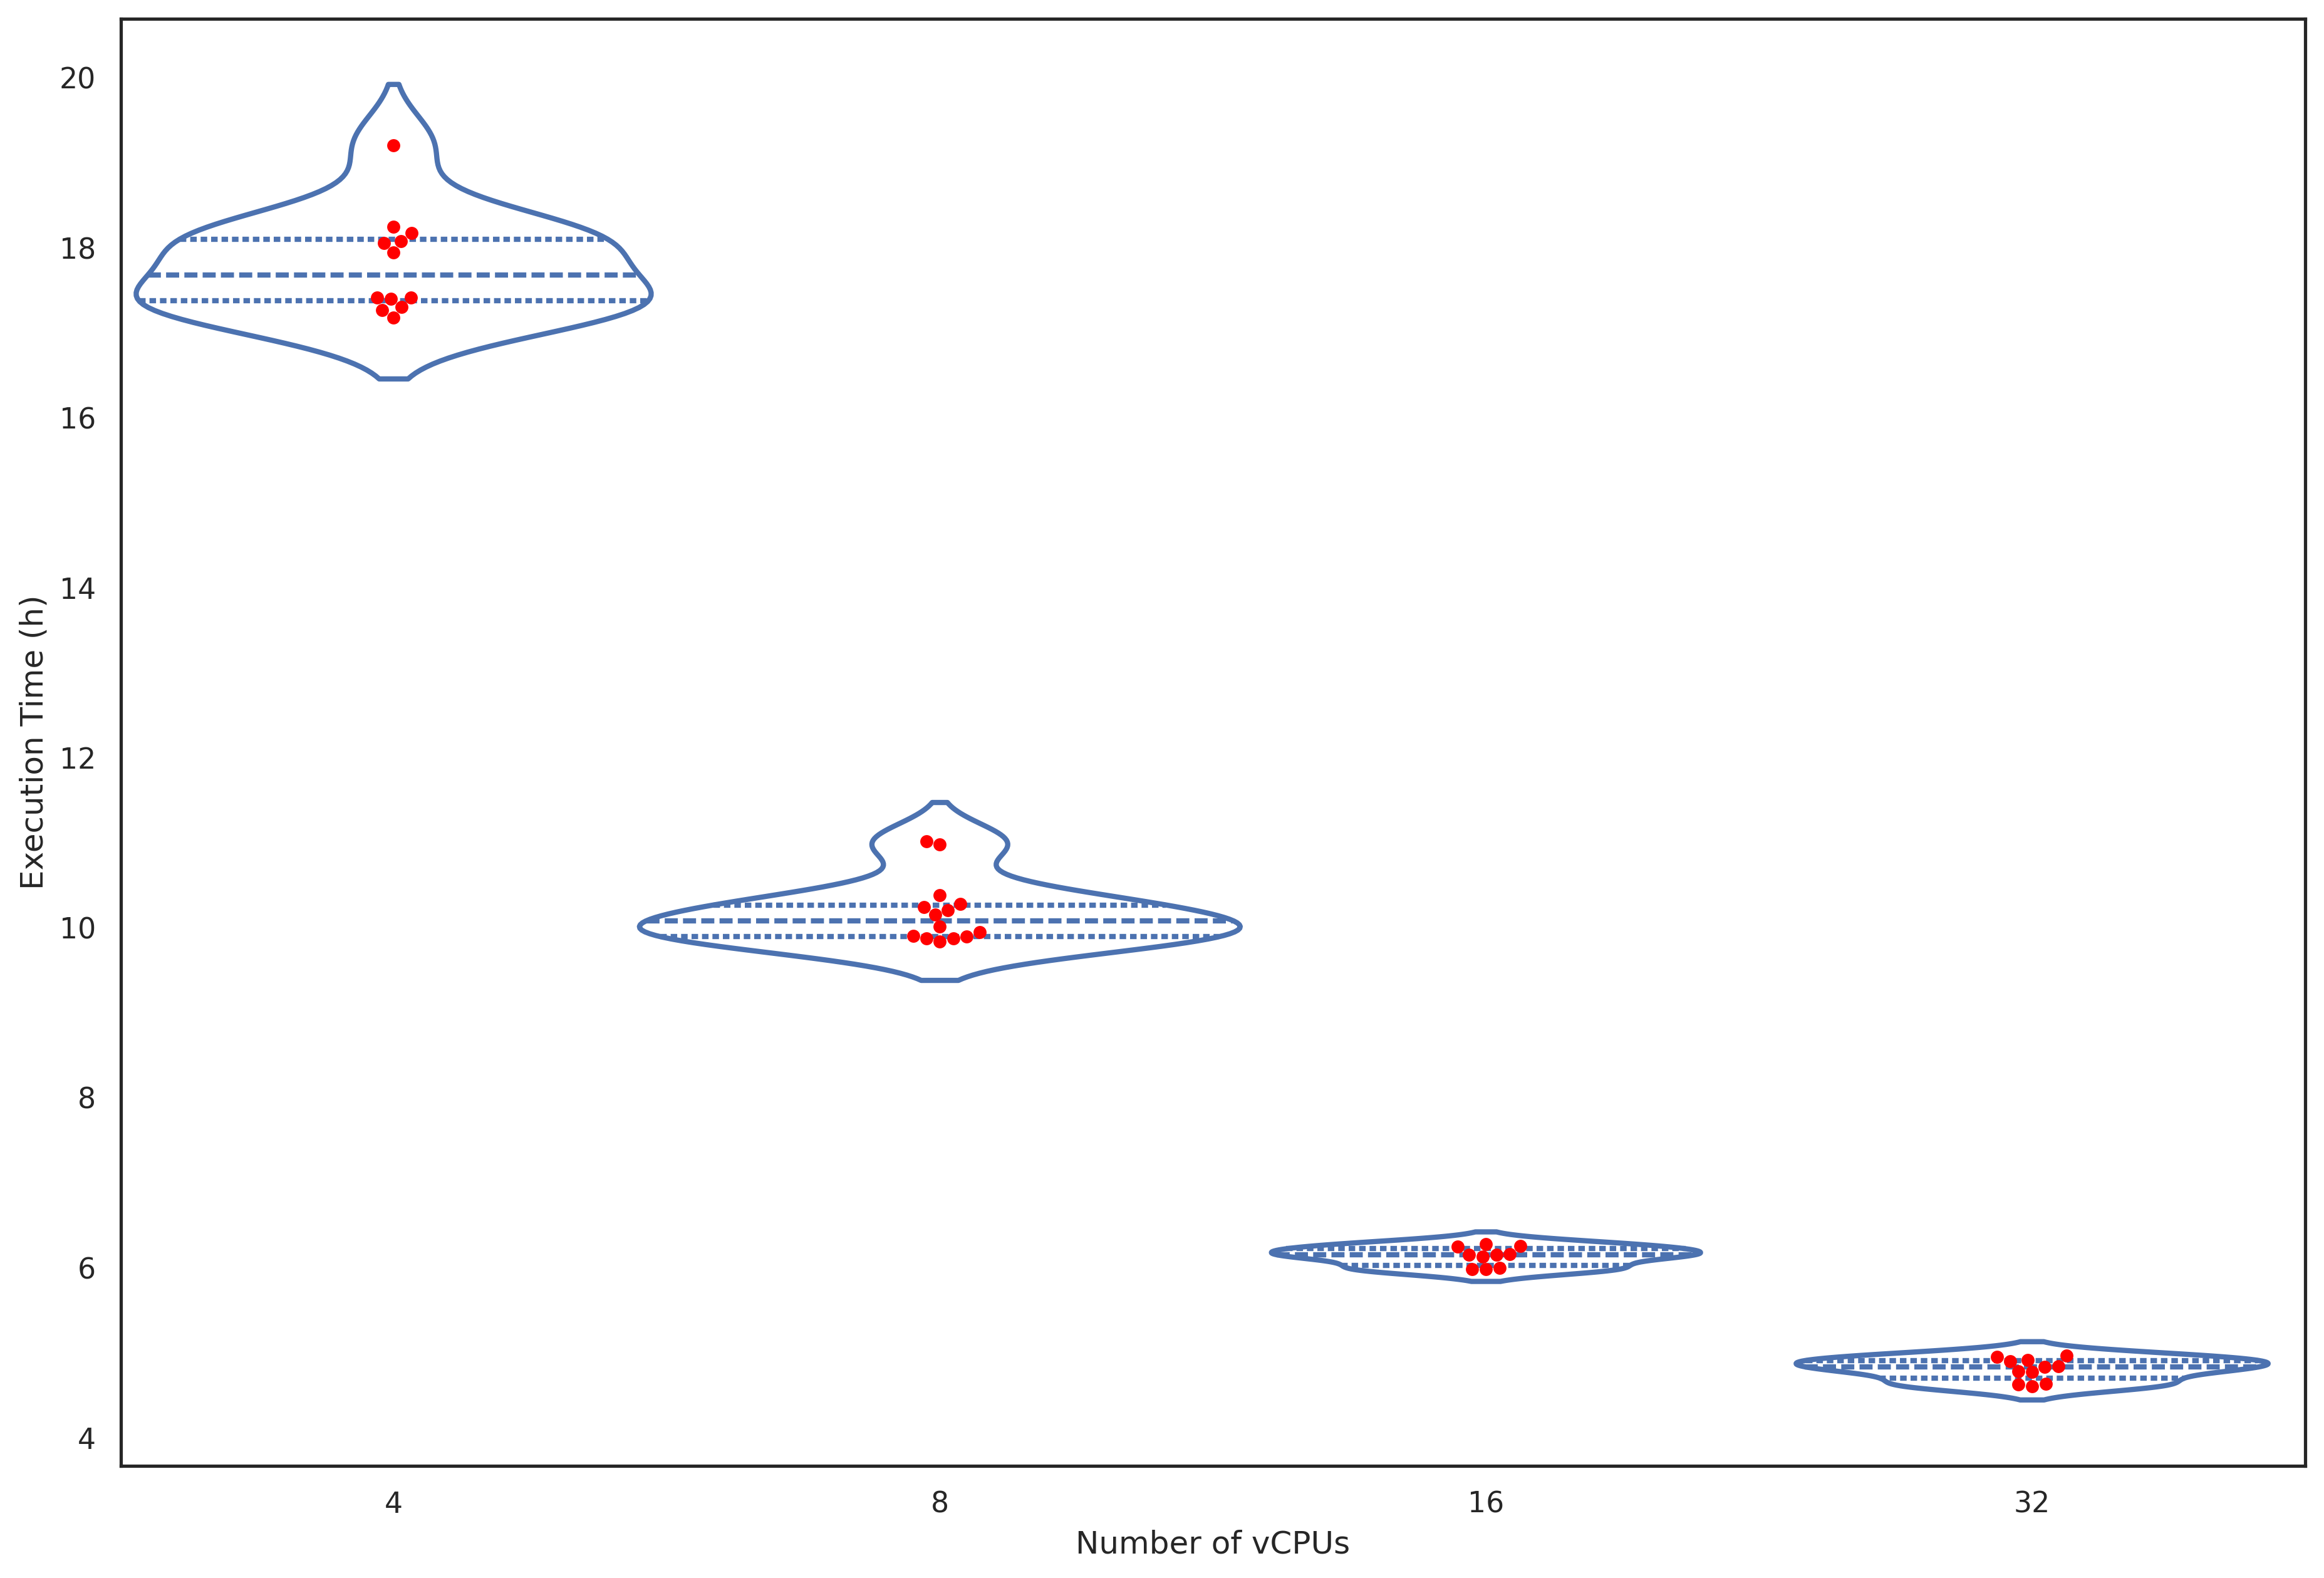

In [26]:
da.show_boxplot(
    daa_time, "Execution Time of DAA Workflow at Varying Parallelism Degrees", metric=metric,
    x_label="Number of vCPUs", y_label="Execution Time (h)", store=True
)

## Normality Test: Shapiro-Wilk and QQ-Plots

In [27]:
normality = ps.test_normality(daa_time, column=metric)
print(normality)

   NCPUS      STAT    PVALUE
0      4  0.863996  0.054874
1      8  0.800150  0.005012
2     16  0.878332  0.124854
3     32  0.900892  0.189542


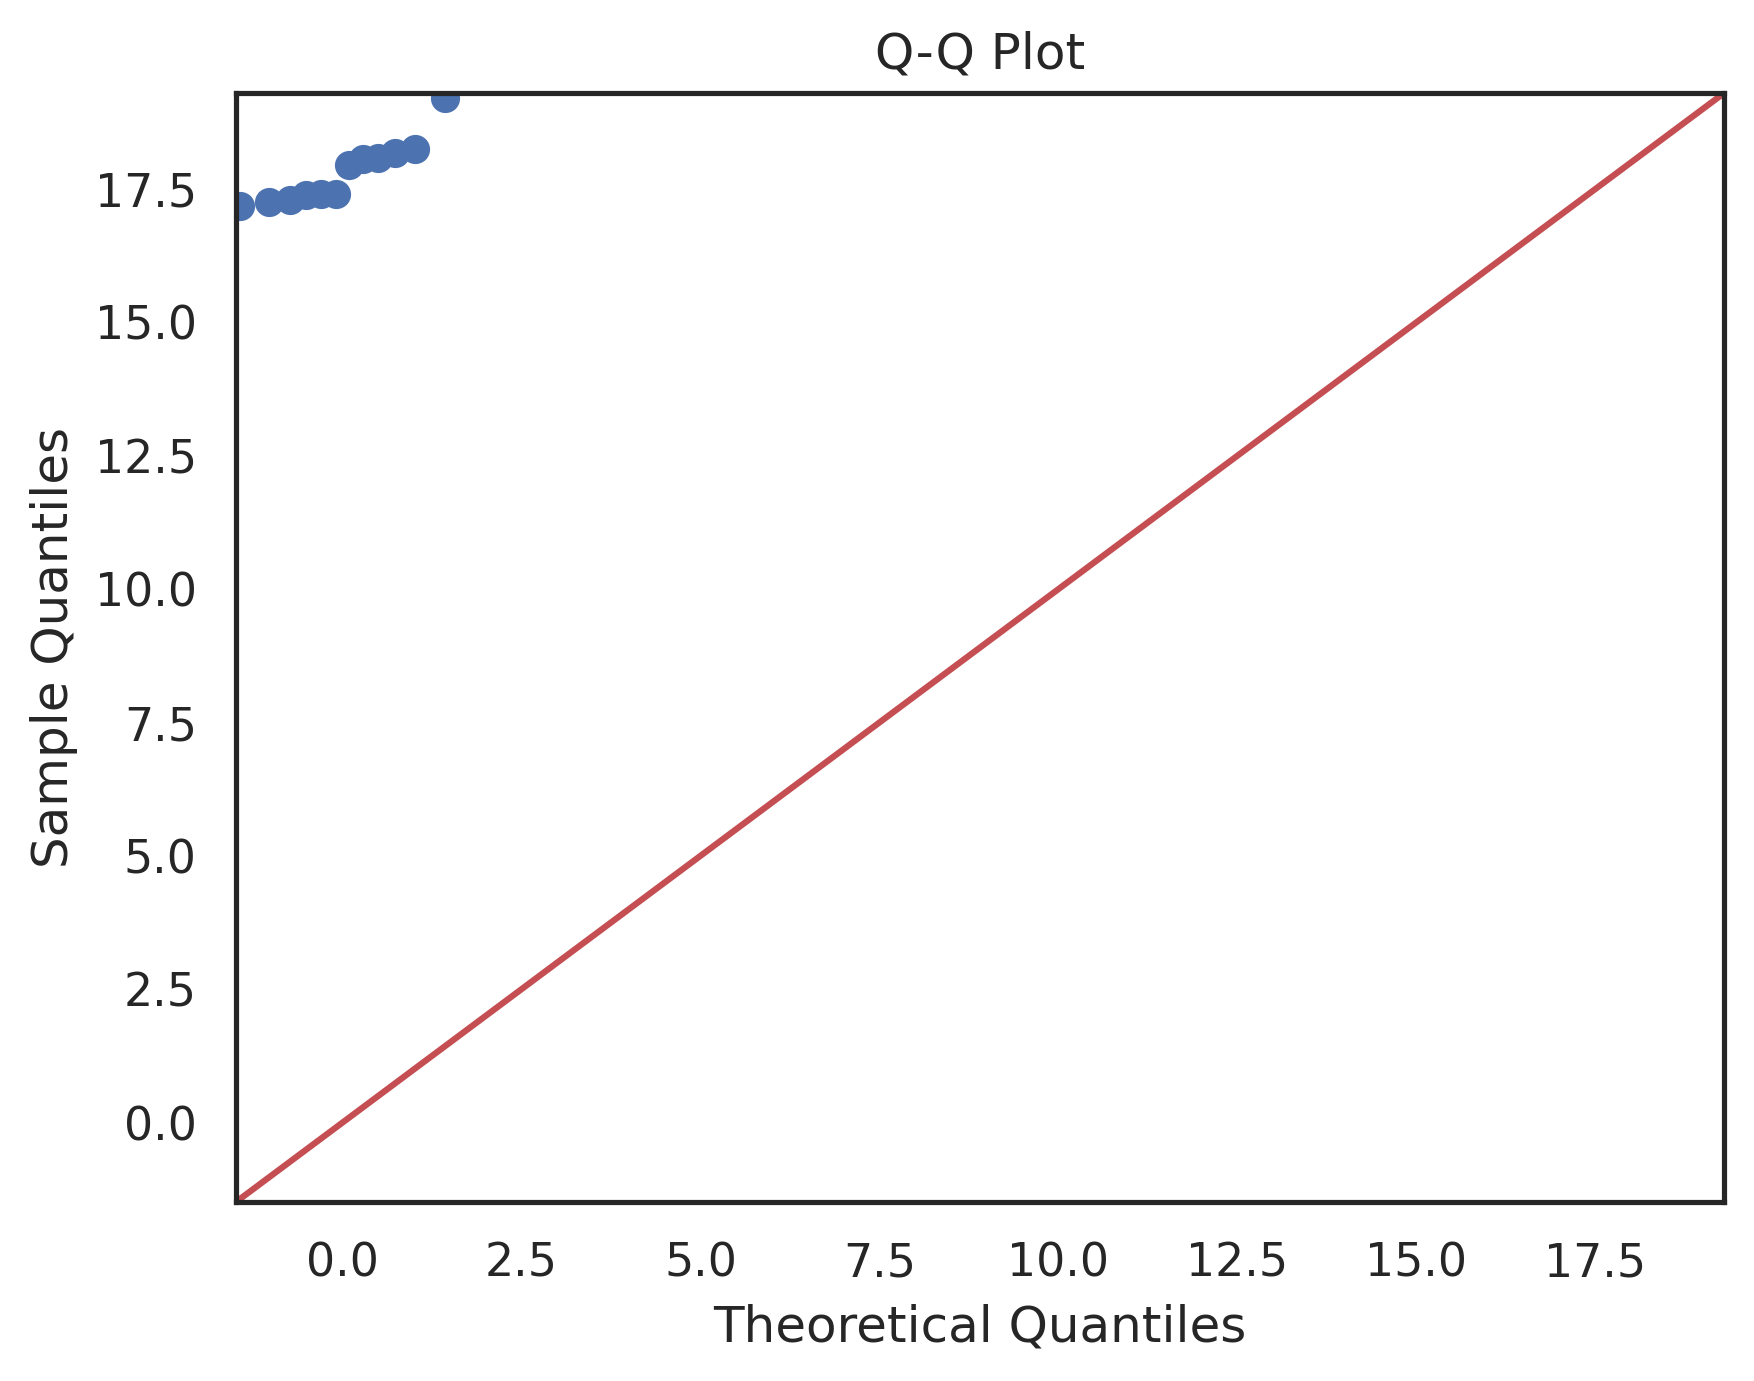

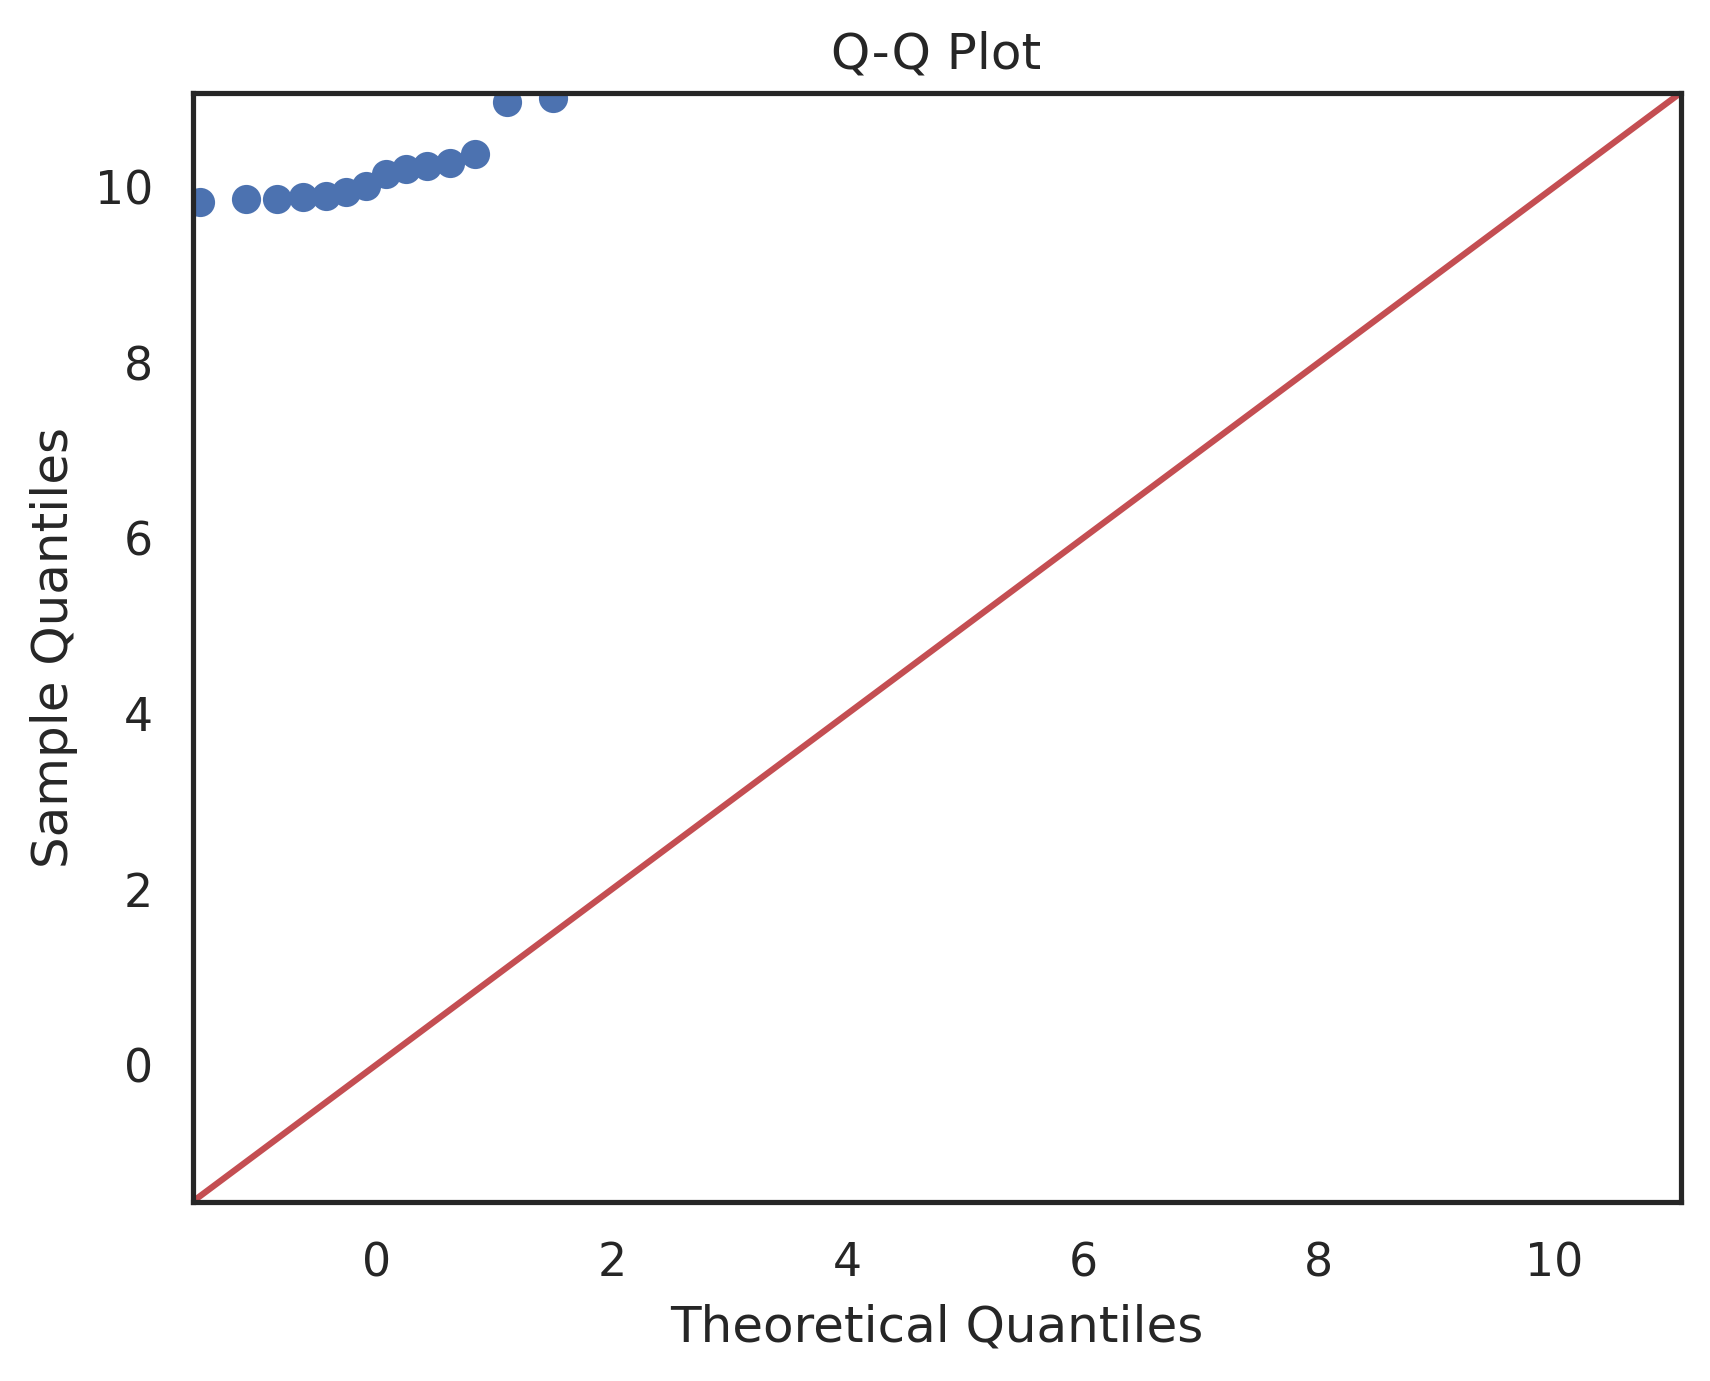

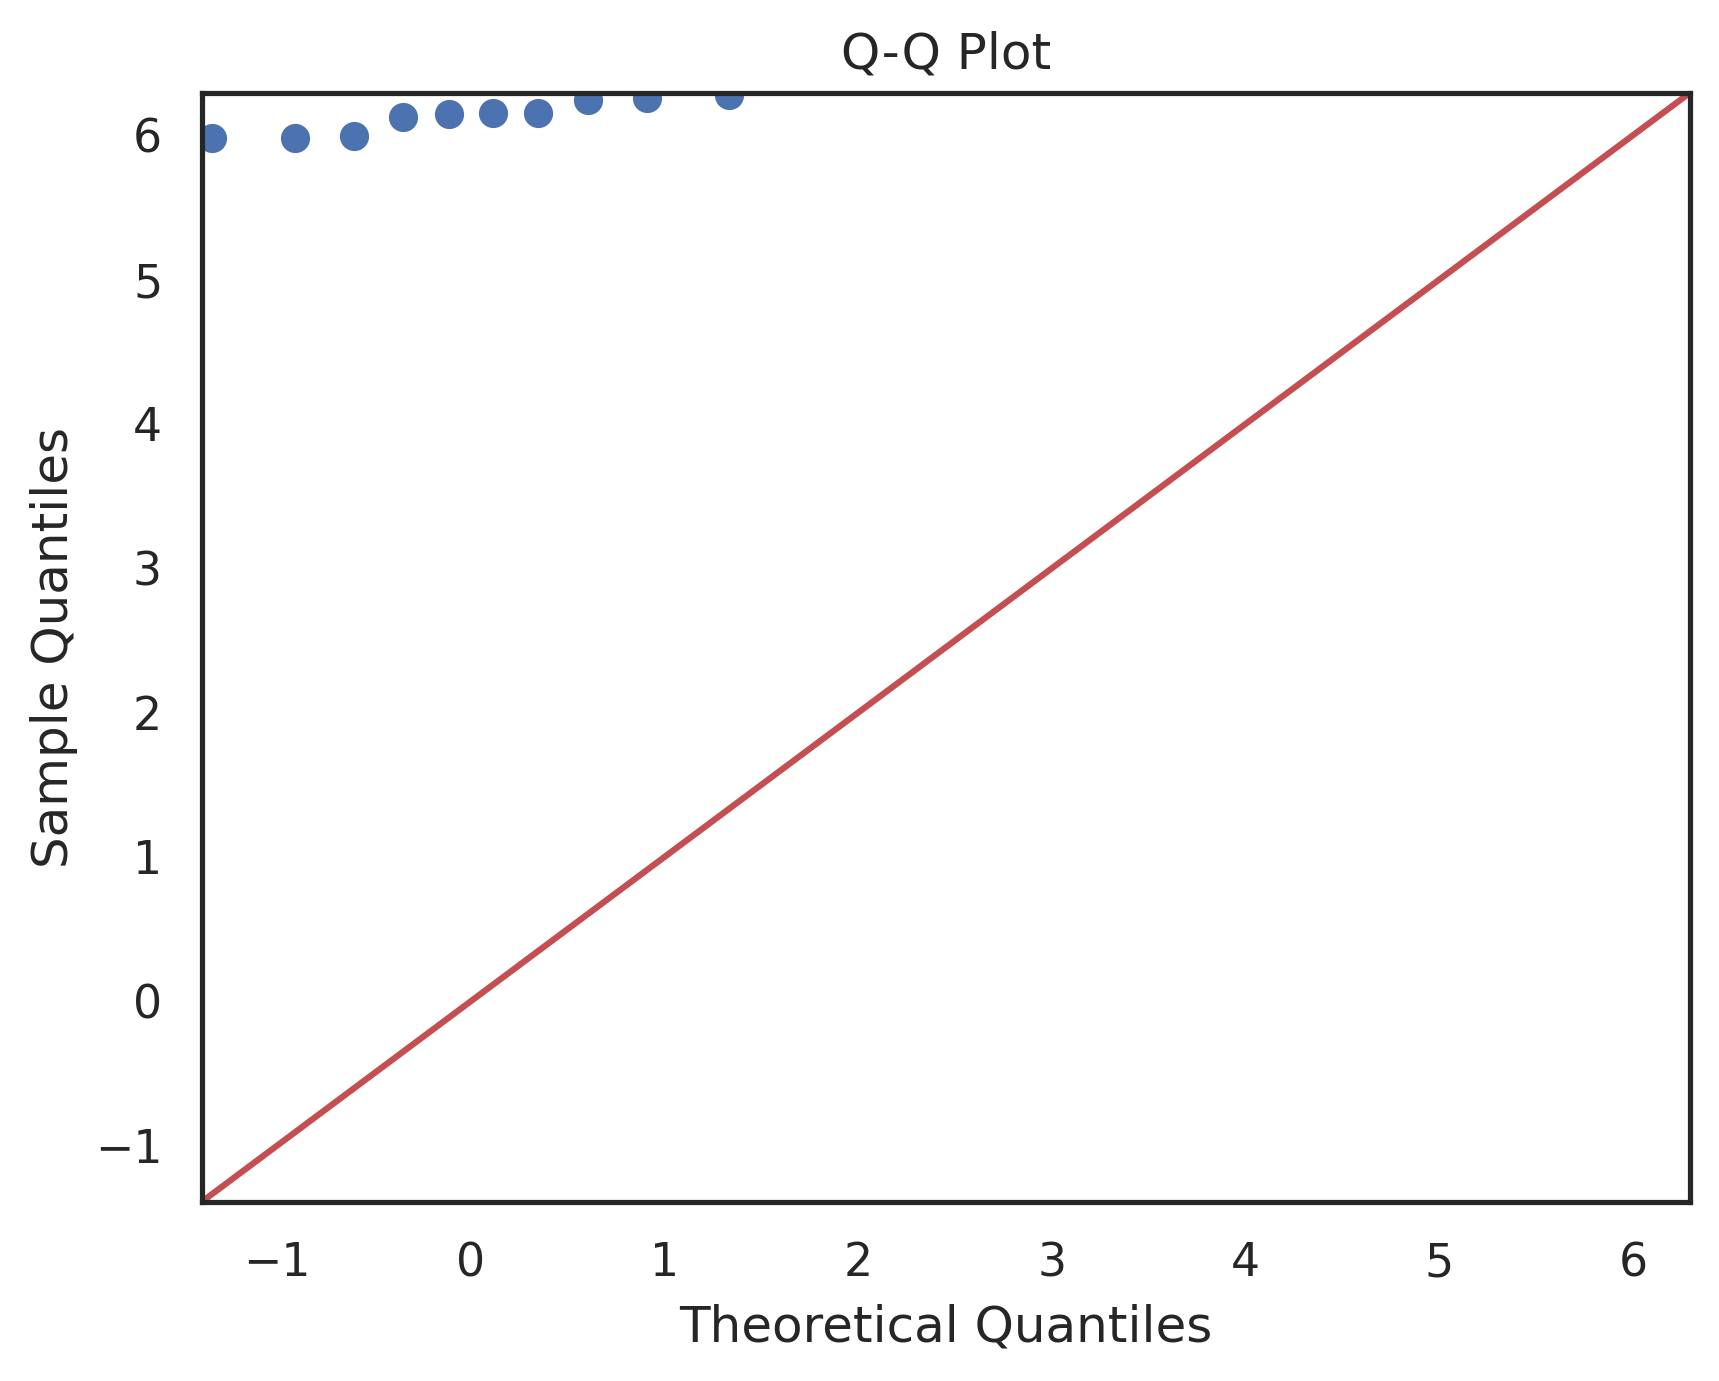

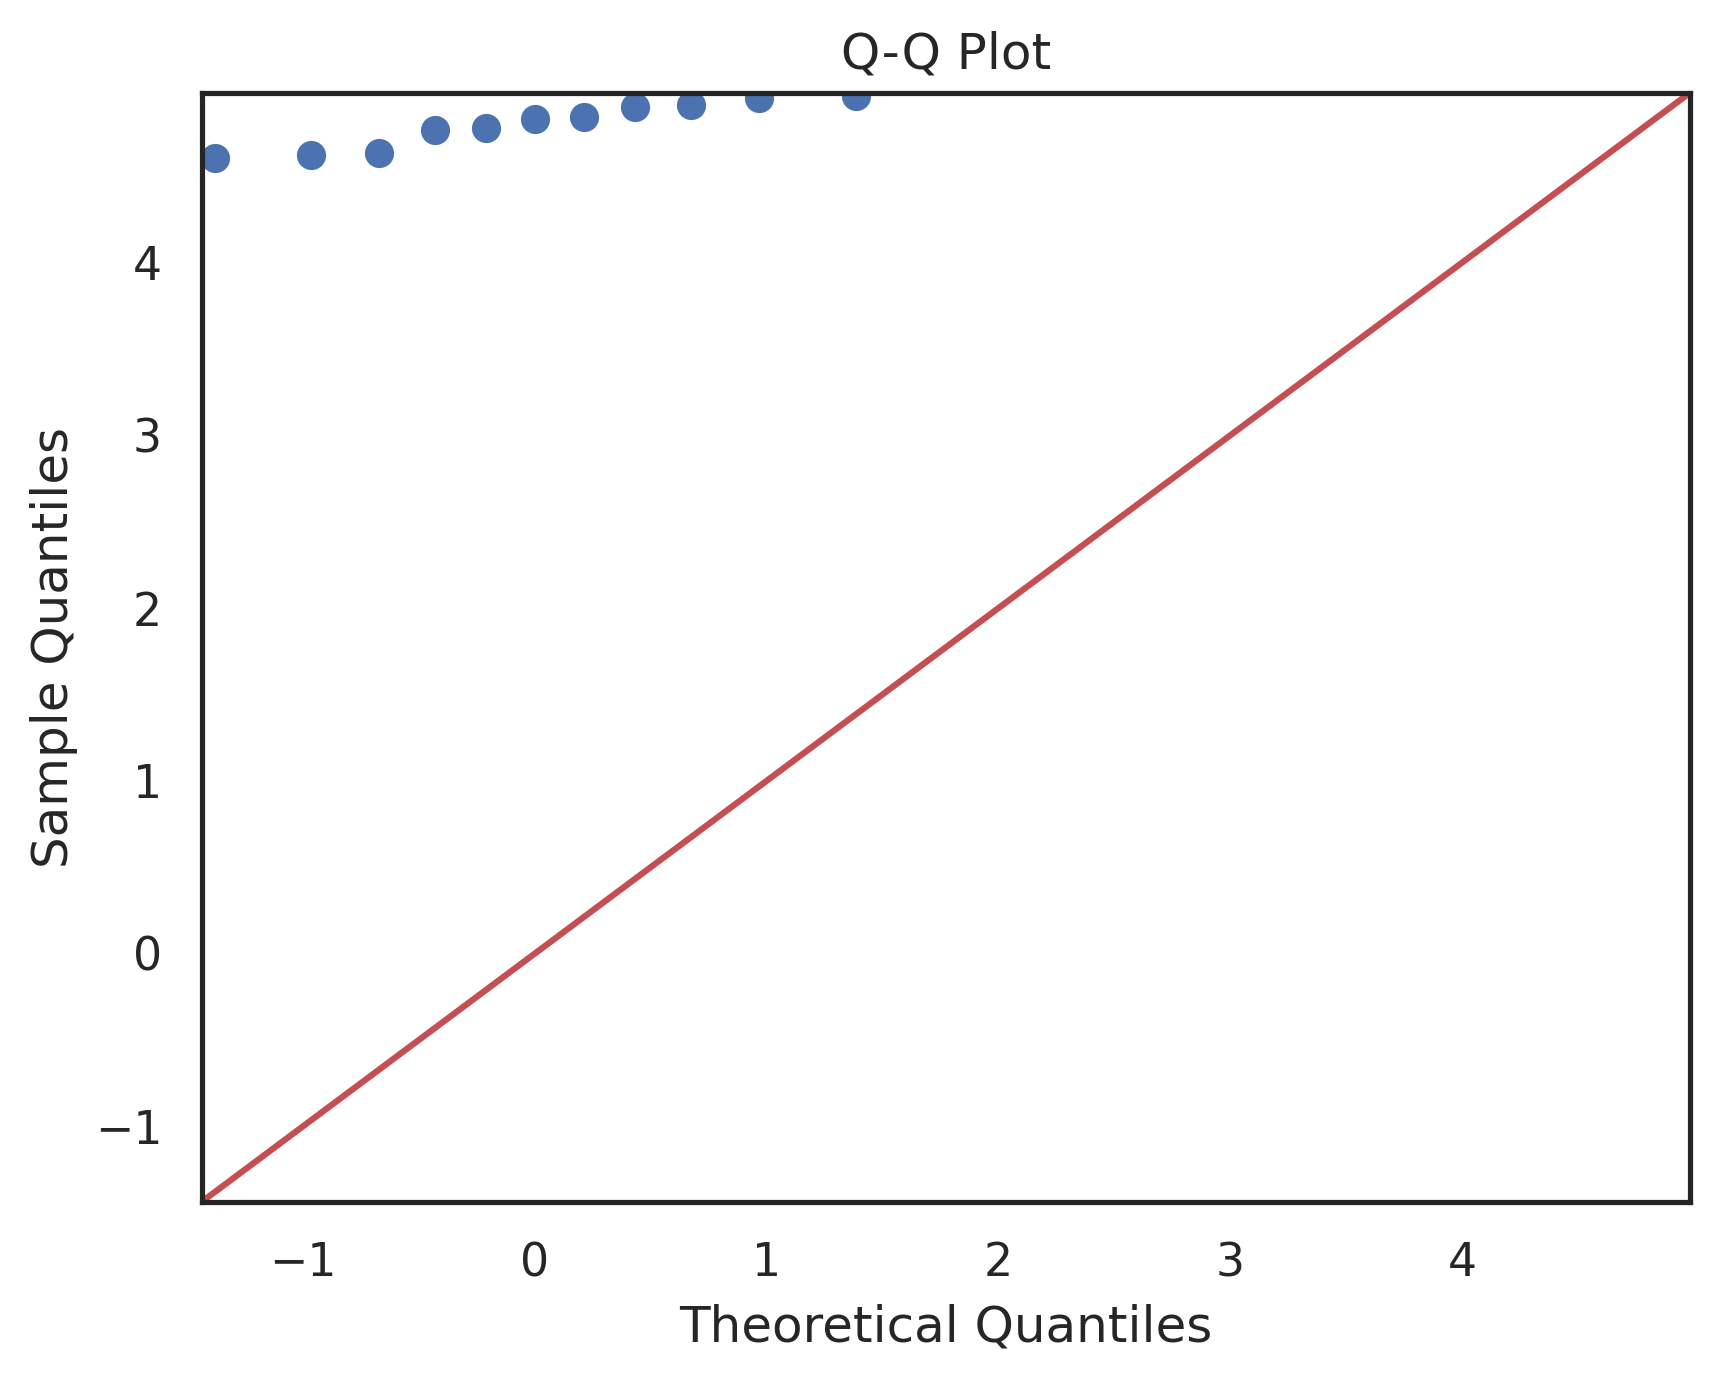

In [28]:
ps.generate_qq(daa_time, column=metric)

## Hypothesis Testing: Kruskal-Wallis

In [29]:
ps.test_hypothesis_kruskal(daa_time, column=metric)

(43.00531914893617, 2.454610623477107e-09)

## Effect Size: Cliff's Delta

In [30]:
ps.calc_cliffs_delta(daa_time, column=metric)

,CPUS-GROUPS,Value,Result
0,"(4, 8)",1.0,large
1,"(8, 16)",1.0,large
2,"(16, 32)",1.0,large


## Effect Size: Percentage Improvement

In [31]:
ps.calc_groups_improvement(daa_time, column=metric)

,CPU-GROUPS,Mean Improvement,Median Improvement,Mean Delta,Median Delta
0,"(4, 8)",74.837591,75.373001,7.621303,7.598750
1,"(8, 16)",66.072391,63.897670,4.051651,3.930417
2,"(16, 32)",27.707207,27.264368,1.330422,1.317778
3,"(4, 32)",270.806775,265.798851,13.003375,12.846944
